# Notebook 5 — Temporal Price Dynamics

## Overview

This notebook examines the predictable temporal structure of Alberta pool prices and the extent to which recent market outcomes contain information about subsequent price conditions.

Notebook 1 documented recurring hourly and seasonal market patterns. Notebooks 2–4 then examined physical scarcity, fuel economics, demand formation, and renewable availability. Notebook 5 isolates a different source of information: calendar structure and market memory.

The notebook examines:

- hourly, weekly, monthly, seasonal, and holiday price patterns;
- the stability of those patterns across years;
- short- and medium-horizon price persistence;
- clustering in price changes and prior volatility;
- transitions into, through, and out of high-price events;
- interactions between calendar position and prior price state; and
- the information-timing and redundancy of candidate temporal features.

The analysis remains descriptive. Current-hour pool price is an outcome, while properly lagged prices and prior-only rolling statistics may be forecast eligible if their publication latency is respected.

The notebook does not repeat the physical-driver analyses from Notebooks 2–4 or estimate the forecasting models assigned to Notebooks 6–8.

## 1. Imports and definitions

This section loads the canonical price and calendar data, audits the prior-only features, and defines the market regimes used for stability checks.

### 1.1 Imports and data

The canonical hourly master dataset remains authoritative. Notebook-specific variables are stored separately in `temporal_features`.

The study period covers Alberta operating years 2015–2025.

In [1]:
# ---------------------------------------------------------------------
# Configure imports and load the canonical master dataset
# ---------------------------------------------------------------------

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display

from config import MASTER_PARQUET, RANDOM_SEED

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)

np.random.seed(RANDOM_SEED)

master = pd.read_parquet(MASTER_PARQUET)

print(
    f"Canonical master loaded: "
    f"{master.shape[0]:,} rows × "
    f"{master.shape[1]:,} columns"
)

Canonical master loaded: 100,033 rows × 494 columns


### 1.2 Coverage and audits

Timestamp integrity, calendar coverage, price coverage, and prior-price feature timing are audited before analysis.

Calendar variables are known in advance. Lagged prices and prior rolling statistics are potentially forecast eligible only when they use observations published before the forecast origin. Current price states, price changes, and event labels remain outcomes.

In [2]:
# ---------------------------------------------------------------------
# Define the study period and required inputs
# ---------------------------------------------------------------------

STUDY_START_YEAR = 2015
STUDY_END_YEAR = 2025

ALBERTA_TIMEZONE = "America/Edmonton"

PRIMARY_SCARCITY_THRESHOLD = 500
PRICE_SCALE_MWH = 50

MINIMUM_CELL_HOURS = 100
MINIMUM_ANNUAL_CELL_HOURS = 10
MINIMUM_YEARS_QUALIFYING = 5

LAG_HORIZONS = [1, 2, 3, 6, 12, 24, 48, 168]

REQUIRED_COLUMNS = [
    "timestamp_utc",
    "timestamp_alberta",
    "local_date",
    "year_alberta",
    "quarter_alberta",
    "month_alberta",
    "month_name_alberta",
    "day_of_week_alberta",
    "hour_alberta",
    "is_weekday",
    "is_weekend",
    "is_holiday",
    "is_day_before_holiday",
    "is_day_after_holiday",
    "holiday_name",
    "season",
    "is_business_hour",
    "pool_price",
    "pool_price_lag_1h",
    "pool_price_lag_2h",
    "pool_price_lag_3h",
    "pool_price_lag_6h",
    "pool_price_lag_12h",
    "pool_price_lag_24h",
    "pool_price_lag_48h",
    "pool_price_lag_168h",
    "pool_price_change_1h",
    "pool_price_std_prior_24h",
    "pool_price_mean_prior_24h",
    "pool_price_max_prior_24h",
]

missing_required_columns = sorted(set(REQUIRED_COLUMNS) - set(master.columns))

if missing_required_columns:
    raise ValueError(
        "Master dataset is missing Notebook 5 columns: "
        f"{missing_required_columns}"
    )

master["timestamp_utc"] = pd.to_datetime(master["timestamp_utc"], utc=True)
master = (master.sort_values("timestamp_utc").loc[master["year_alberta"].between(STUDY_START_YEAR, STUDY_END_YEAR)].copy().reset_index(drop=True))
duplicate_timestamps = int(master["timestamp_utc"].duplicated().sum())
non_hourly_intervals = int(master["timestamp_utc"].diff().iloc[1:].ne(pd.Timedelta(hours=1)).sum())

if duplicate_timestamps or non_hourly_intervals:
    raise ValueError(
        "Hourly timestamp validation failed: "
        f"duplicates={duplicate_timestamps}, "
        f"non_hourly_intervals={non_hourly_intervals}"
    )

print(
    "Selected period:",
    master["timestamp_alberta"].min(),
    "to",
    master["timestamp_alberta"].max(),
)

Selected period: 2015-01-01 00:00:00-07:00 to 2025-12-31 23:00:00-07:00


In [3]:
# ---------------------------------------------------------------------
# Audit annual coverage and required inputs
# ---------------------------------------------------------------------

study_years = pd.Index(range(STUDY_START_YEAR, STUDY_END_YEAR + 1), name="year_alberta")
observed_hours = (master.groupby("year_alberta").size().reindex(study_years, fill_value=0))

expected_hours = pd.Series(
    {
        year: len(
            pd.date_range(
                start=f"{year}-01-01",
                end=f"{year + 1}-01-01",
                inclusive="left",
                freq="h",
                tz=ALBERTA_TIMEZONE,
            )
        )
        for year in study_years
    },
    name="expected_hours",
)

annual_coverage = pd.concat(
    [
        expected_hours,
        observed_hours.rename("observed_hours"),
    ],
    axis=1,
)

annual_coverage["unobserved_hours"] = (
    annual_coverage["expected_hours"]
    - annual_coverage["observed_hours"]
)

annual_coverage["coverage_pct"] = (
    annual_coverage["observed_hours"]
    / annual_coverage["expected_hours"]
    * 100
)

AUDIT_COLUMNS = [
    "pool_price",
    "pool_price_lag_1h",
    "pool_price_lag_24h",
    "pool_price_lag_168h",
    "pool_price_mean_prior_24h",
    "pool_price_std_prior_24h",
    "pool_price_max_prior_24h",
    "hour_alberta",
    "day_of_week_alberta",
    "month_alberta",
    "is_holiday",
    "season",
]

input_audit = pd.DataFrame({
    "missing_hours": master[AUDIT_COLUMNS].isna().sum(),
    "coverage_pct": master[AUDIT_COLUMNS].notna().mean() * 100,
    "first_reported": [master.loc[master[column].notna(), "timestamp_alberta"].min() for column in AUDIT_COLUMNS],
    "last_reported": [master.loc[master[column].notna(), "timestamp_alberta"].max() for column in AUDIT_COLUMNS],
    "minimum": [master[column].min() for column in AUDIT_COLUMNS],
    "maximum": [master[column].max() for column in AUDIT_COLUMNS],
}, index=AUDIT_COLUMNS)

display(annual_coverage.round(3))

display(input_audit.round({"coverage_pct": 3, "minimum": 3, "maximum": 3}))

,expected_hours,observed_hours,unobserved_hours,coverage_pct
2015,8760,8760,0,100.0
2016,8784,8784,0,100.0
2017,8760,8760,0,100.0
2018,8760,8760,0,100.0
2019,8760,8760,0,100.0
2020,8784,8784,0,100.0
2021,8760,8760,0,100.0
2022,8760,8760,0,100.0
2023,8760,8760,0,100.0
2024,8784,8784,0,100.0


,missing_hours,coverage_pct,first_reported,last_reported,minimum,maximum
pool_price,0,100.000,2015-01-01 00:00:00-07:00,2025-12-31 23:00:00-07:00,0.0,999.99
pool_price_lag_1h,1,99.999,2015-01-01 01:00:00-07:00,2025-12-31 23:00:00-07:00,0.0,999.99
pool_price_lag_24h,24,99.975,2015-01-02 00:00:00-07:00,2025-12-31 23:00:00-07:00,0.0,999.99
pool_price_lag_168h,168,99.826,2015-01-08 00:00:00-07:00,2025-12-31 23:00:00-07:00,0.0,999.99
pool_price_mean_prior_24h,3,99.997,2015-01-01 03:00:00-07:00,2025-12-31 23:00:00-07:00,0.264167,793.487917
pool_price_std_prior_24h,3,99.997,2015-01-01 03:00:00-07:00,2025-12-31 23:00:00-07:00,0.029559,461.696633
pool_price_max_prior_24h,3,99.997,2015-01-01 03:00:00-07:00,2025-12-31 23:00:00-07:00,3.21,999.99
hour_alberta,0,100.000,2015-01-01 00:00:00-07:00,2025-12-31 23:00:00-07:00,0,23
day_of_week_alberta,0,100.000,2015-01-01 00:00:00-07:00,2025-12-31 23:00:00-07:00,0,6
month_alberta,0,100.000,2015-01-01 00:00:00-07:00,2025-12-31 23:00:00-07:00,1,12


### 1.3 Information timing

| Variable | Historical role | Forecast-time treatment |
|---|---|---|
| Hour, weekday, month and holiday | Recurring calendar structure | Known in advance |
| Current pool price | Outcome being explained | Not an input for the same hour |
| Lagged pool price | Recent market history | Eligible after respecting publication latency |
| Prior rolling mean, maximum and volatility | Historical market state | Eligible only when the window excludes the current hour |
| Current price change | Realized transition outcome | Lag before predictive use |
| Current scarcity event | Event outcome | Forecast target, not predictor |
| Structural regime | Historical stability context | Use cautiously as calendar context |

This notebook can assess whether prior prices contain descriptive information about the current hour. Formal forecast value must still be established through time-based out-of-sample evaluation.

In [4]:
# Validate lagged and prior-only feature timing
expected_lag_1h = master["pool_price"].shift(1)

lag_comparison = pd.DataFrame({
    "reported": master["pool_price_lag_1h"],
    "expected": expected_lag_1h
}).dropna()

maximum_lag_difference = (lag_comparison["reported"] - lag_comparison["expected"]).abs().max()
lag_missingness_matches = master["pool_price_lag_1h"].isna().equals(
    expected_lag_1h.isna()
)

# The canonical feature pipeline requires three prior observations.
expected_prior_std_24h = (
    master["pool_price"]
    .shift(1)
    .rolling(window=24, min_periods=3)
    .std(ddof=1)
)

rolling_comparison = pd.DataFrame({
    "reported": master["pool_price_std_prior_24h"],
    "expected": expected_prior_std_24h
}).dropna()

maximum_rolling_difference = (rolling_comparison["reported"] - rolling_comparison["expected"]).abs().max()
rolling_missingness_matches = master["pool_price_std_prior_24h"].isna().equals(
    expected_prior_std_24h.isna()
)

timing_audit = pd.DataFrame([
    {"feature": "One-hour pool-price lag", "maximum_absolute_difference": maximum_lag_difference, "comparison_hours": len(lag_comparison), "missingness_matches": lag_missingness_matches},
    {"feature": "Prior 24-hour price volatility", "maximum_absolute_difference": maximum_rolling_difference, "comparison_hours": len(rolling_comparison), "missingness_matches": rolling_missingness_matches}
])

assert lag_missingness_matches, "The one-hour price lag has unexpected missingness."
assert rolling_missingness_matches, "The prior 24-hour volatility field has unexpected missingness."
assert np.isclose(maximum_lag_difference, 0), "The one-hour price lag does not match shift(1)."
assert np.isclose(maximum_rolling_difference, 0), "The prior 24-hour volatility field does not match a three-observation, current-hour-excluding rolling window."

display(timing_audit)

,feature,maximum_absolute_difference,comparison_hours,missingness_matches
0,One-hour pool-price lag,0.0,96431,True
1,Prior 24-hour price volatility,0.0,96429,True


### 1.4 Market regimes and variables

Structural regimes are retained only to test whether temporal relationships remain stable as Alberta’s generation mix changes. They are defined using external calendar boundaries rather than price outcomes.

Pool-price transformations, states, lag ranks, volatility ranks, and holiday classifications are constructed without modifying `master`.

In [5]:
# Define structural regimes and reusable helpers

STRUCTURAL_REGIME_ORDER = ["Coal-dominant", "Coal-to-gas transition", "Late coal exit and renewable buildout", "Coal-free gas-renewable system"]

structural_regime = pd.Categorical(
    np.select([master["year_alberta"].le(2017), master["year_alberta"].le(2021), master["year_alberta"].le(2024)], STRUCTURAL_REGIME_ORDER[:3], default=STRUCTURAL_REGIME_ORDER[3]),
    categories=STRUCTURAL_REGIME_ORDER, ordered=True
)

DAY_ORDER = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

MONTH_ORDER = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]

PRICE_STATE_ORDER = ["Below $100", "$100–$299", "$300–$499", "$500–$899", "$900+"]

HOLIDAY_STATE_ORDER = ["Ordinary day", "Day before holiday", "Holiday", "Day after holiday"]


def within_year_percentile(values):
    frame = pd.DataFrame({"year_alberta": master["year_alberta"], "value": values})
    return frame.groupby("year_alberta")["value"].rank(method="average", pct=True)


def percentile_to_decile(percentile):
    return np.floor(percentile * 10).clip(upper=9).astype("Int64")


def build_episode_id(event):
    event = event.fillna(False).astype(bool)
    episode_start = event & ~event.shift(fill_value=False)
    return episode_start.cumsum().where(event)


def build_year_decile_summary(values, event):
    percentile = within_year_percentile(values)
    decile = percentile_to_decile(percentile)

    frame = pd.DataFrame({"year_alberta": master["year_alberta"], "decile": decile, "event": event}).dropna()

    annual_base = frame.groupby("year_alberta")["event"].mean().rename("annual_base_rate")

    summary = (
        frame.groupby(["year_alberta", "decile"], observed=True)
        .agg(hours=("event", "size"), event_rate=("event", "mean"))
        .reset_index()
        .merge(annual_base, on="year_alberta", how="left")
    )

    summary["event_lift"] = summary["event_rate"] / summary["annual_base_rate"].replace(0, np.nan)
    return summary


def plot_annotated_heatmap(
    summary, row_column, column_column, value_column, count_column,
    row_order, column_order, title, row_label, column_label,
    colorbar_label, minimum_hours=MINIMUM_CELL_HOURS, cmap="YlOrRd",
    value_format=".2f"
):
    values = (
        summary.pivot(index=row_column, columns=column_column, values=value_column)
        .reindex(index=row_order, columns=column_order)
    )

    counts = (
        summary.pivot(index=row_column, columns=column_column, values=count_column)
        .reindex(index=row_order, columns=column_order)
    )

    displayed_values = values.where(counts.ge(minimum_hours))

    fig, ax = plt.subplots(figsize=(max(9, len(column_order) * 0.65), max(5, len(row_order) * 0.55)))

    image = ax.imshow(displayed_values, aspect="auto", cmap=cmap)

    ax.set_xticks(range(len(column_order)))
    ax.set_xticklabels(column_order, rotation=30, ha="right")
    ax.set_yticks(range(len(row_order)))
    ax.set_yticklabels(row_order)

    for row in range(displayed_values.shape[0]):
        for column in range(displayed_values.shape[1]):
            value = displayed_values.iloc[row, column]
            count = counts.iloc[row, column]

            if np.isfinite(value):
                ax.text(
                    column, row,
                    f"{value:{value_format}}\n(n={count:,.0f})",
                    ha="center", va="center", fontsize=7
                )

    ax.set_title(title)
    ax.set_xlabel(column_label)
    ax.set_ylabel(row_label)
    fig.colorbar(image, ax=ax, label=colorbar_label)

    plt.tight_layout()
    plt.show()


In [6]:
# Construct Notebook 5 variables without modifying master

temporal_features = pd.DataFrame(index=master.index)

temporal_features["primary_scarcity_event"] = master["pool_price"].ge(PRIMARY_SCARCITY_THRESHOLD)

temporal_features["price_asinh"] = np.arcsinh(master["pool_price"] / PRICE_SCALE_MWH)

temporal_features["price_percentile_within_year"] = within_year_percentile(master["pool_price"])

temporal_features["price_state"] = pd.cut(
    master["pool_price"],
    bins=[-np.inf, 100, 300, 500, 900, np.inf],
    labels=PRICE_STATE_ORDER,
    right=False
)

temporal_features["prior_price_state"] = pd.cut(
    master["pool_price_lag_1h"],
    bins=[-np.inf, 100, 300, 500, 900, np.inf],
    labels=PRICE_STATE_ORDER,
    right=False
)

temporal_features["prior_price_percentile_within_year"] = within_year_percentile(master["pool_price_lag_1h"])
temporal_features["prior_price_decile"] = percentile_to_decile(temporal_features["prior_price_percentile_within_year"])

temporal_features["absolute_price_change_1h"] = (
    master["pool_price"] - master["pool_price_lag_1h"]
).abs()

temporal_features["prior_volatility_24h"] = master["pool_price_std_prior_24h"]

temporal_features["prior_volatility_percentile_within_year"] = within_year_percentile(
    temporal_features["prior_volatility_24h"]
)

temporal_features["prior_volatility_decile"] = percentile_to_decile(
    temporal_features["prior_volatility_percentile_within_year"]
)

temporal_features["day_name"] = master["day_of_week_alberta"].map(dict(enumerate(DAY_ORDER)))

temporal_features["month_name"] = master["month_alberta"].map({
    month: name for month, name in enumerate(MONTH_ORDER, start=1)
})

temporal_features["holiday_state"] = pd.Categorical(
    np.select(
        [
            master["is_holiday"].eq(1),
            master["is_day_before_holiday"].eq(1),
            master["is_day_after_holiday"].eq(1)
        ],
        ["Holiday", "Day before holiday", "Day after holiday"],
        default="Ordinary day"
    ),
    categories=HOLIDAY_STATE_ORDER,
    ordered=True
)

display(temporal_features.head())


,primary_scarcity_event,price_asinh,price_percentile_within_year,price_state,prior_price_state,prior_price_percentile_within_year,prior_price_decile,absolute_price_change_1h,prior_volatility_24h,prior_volatility_percentile_within_year,prior_volatility_decile,day_name,month_name,holiday_state
0,False,0.692347,0.926712,Below $100,NaN,NaN,<NA>,NaN,NaN,NaN,<NA>,Thursday,January,Holiday
1,False,0.646429,0.906393,Below $100,Below $100,0.926704,9,2.83,NaN,NaN,<NA>,Thursday,January,Holiday
2,False,0.441515,0.670662,Below $100,Below $100,0.906382,9,11.82,NaN,NaN,<NA>,Thursday,January,Holiday
3,False,0.409462,0.555822,Below $100,Below $100,0.670625,6,1.75,7.771141,0.701039,7,Thursday,January,Holiday
4,False,0.404665,0.529966,Below $100,Below $100,0.555771,5,0.26,8.258890,0.716455,7,Thursday,January,Holiday


## 2. Calendar patterns

Calendar effects are examined before price memory because they represent known-in-advance structure.

The analysis asks:

1. At what hours are typical and upper-tail prices highest?
2. How do weekday and weekend profiles differ?
3. Which month–hour combinations are consistently expensive?
4. Do intraday scarcity patterns persist across years?
5. Do holidays differ from comparable non-holiday hours?

Current prices are outcomes in these comparisons. Calendar variables themselves are known before the forecast origin.

,hours,average_pool_price,median_pool_price,price_90th_percentile,scarcity_rate,scarcity_rate_pct
hour_alberta,,,,,,
0,4018,42.35,29.76,75.79,0.00,0.30
1,4029,38.62,28.89,69.13,0.00,0.22
2,4007,36.75,28.22,67.45,0.00,0.17
3,4018,36.07,27.95,65.88,0.00,0.17
4,4018,37.27,28.40,68.37,0.00,0.20
5,4018,42.88,29.14,73.37,0.01,0.55
6,4018,57.53,31.62,95.92,0.02,1.54
7,4018,59.57,32.30,92.37,0.02,1.89
8,4018,61.85,33.25,94.92,0.02,1.92


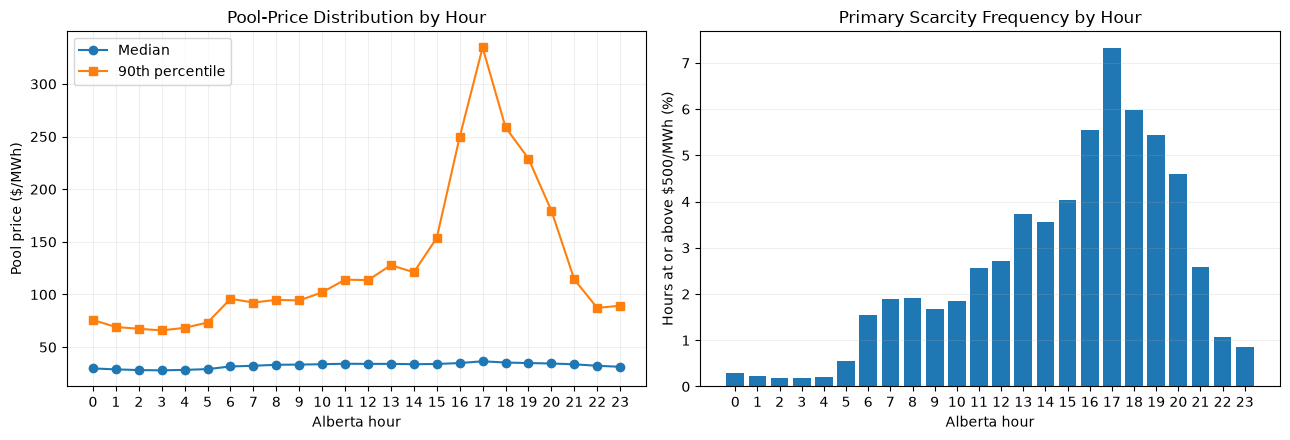

In [7]:
# ---------------------------------------------------------------------
# Summarize the hourly price and scarcity profile
# ---------------------------------------------------------------------

hourly_price_profile = (
    pd.DataFrame({
        "hour_alberta": master["hour_alberta"],
        "pool_price": master["pool_price"],
        "scarcity_event": temporal_features["primary_scarcity_event"],
    }).groupby("hour_alberta").agg(
        hours = ("pool_price", "size"),
        average_pool_price = ("pool_price", "mean"),
        median_pool_price = ("pool_price", "median"),
        price_90th_percentile = ("pool_price", lambda series: series.quantile(0.90)),
        scarcity_rate = ("scarcity_event", "mean"),
    )
)

hourly_price_profile["scarcity_rate_pct"] = (hourly_price_profile["scarcity_rate"] * 100)

display(hourly_price_profile.round(2))

fig, axes = plt.subplots(
    1,
    2, 
    figsize = (13, 4.5),
)

axes[0].plot(
    hourly_price_profile.index,
    hourly_price_profile["median_pool_price"], marker="o", label="Median",
)

axes[0].plot(
    hourly_price_profile.index,
    hourly_price_profile["price_90th_percentile"],marker="s", label="90th percentile",
)

axes[0].set_title("Pool-Price Distribution by Hour")
axes[0].set_xlabel("Alberta hour")
axes[0].set_ylabel("Pool price ($/MWh)")
axes[0].set_xticks(range(24))
axes[0].grid(alpha=0.20)
axes[0].legend()

axes[1].bar(
    hourly_price_profile.index,
    hourly_price_profile["scarcity_rate_pct"],
)

axes[1].set_title("Primary Scarcity Frequency by Hour")
axes[1].set_xlabel("Alberta hour")
axes[1].set_ylabel(
    "Hours at or above $500/MWh (%)"
)
axes[1].set_xticks(range(24))
axes[1].grid(axis="y", alpha=0.20)

plt.tight_layout()
plt.show()

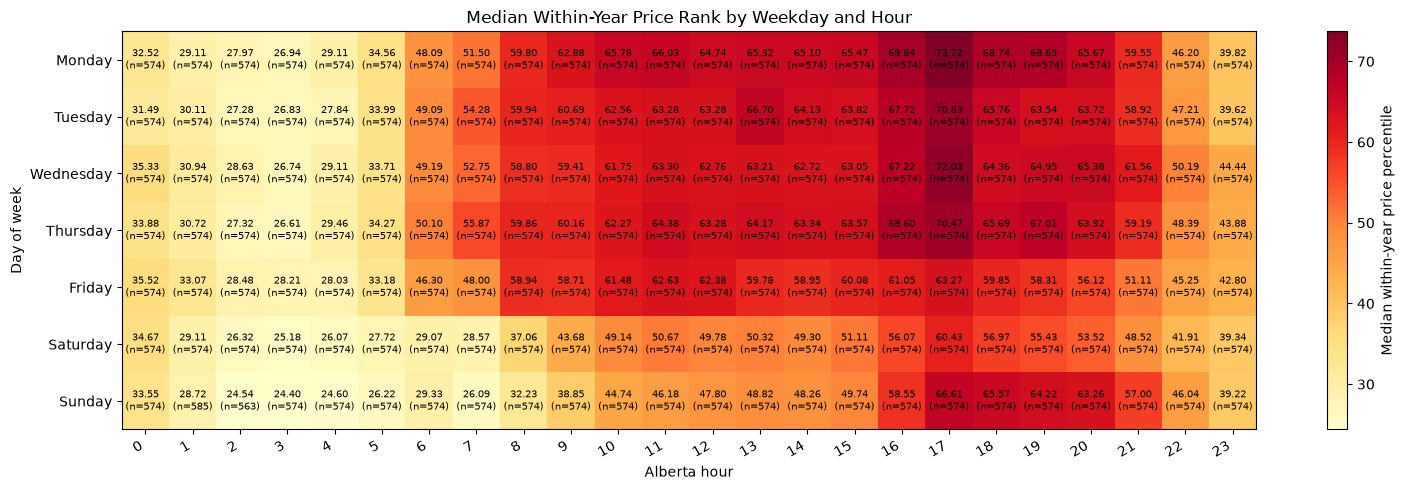

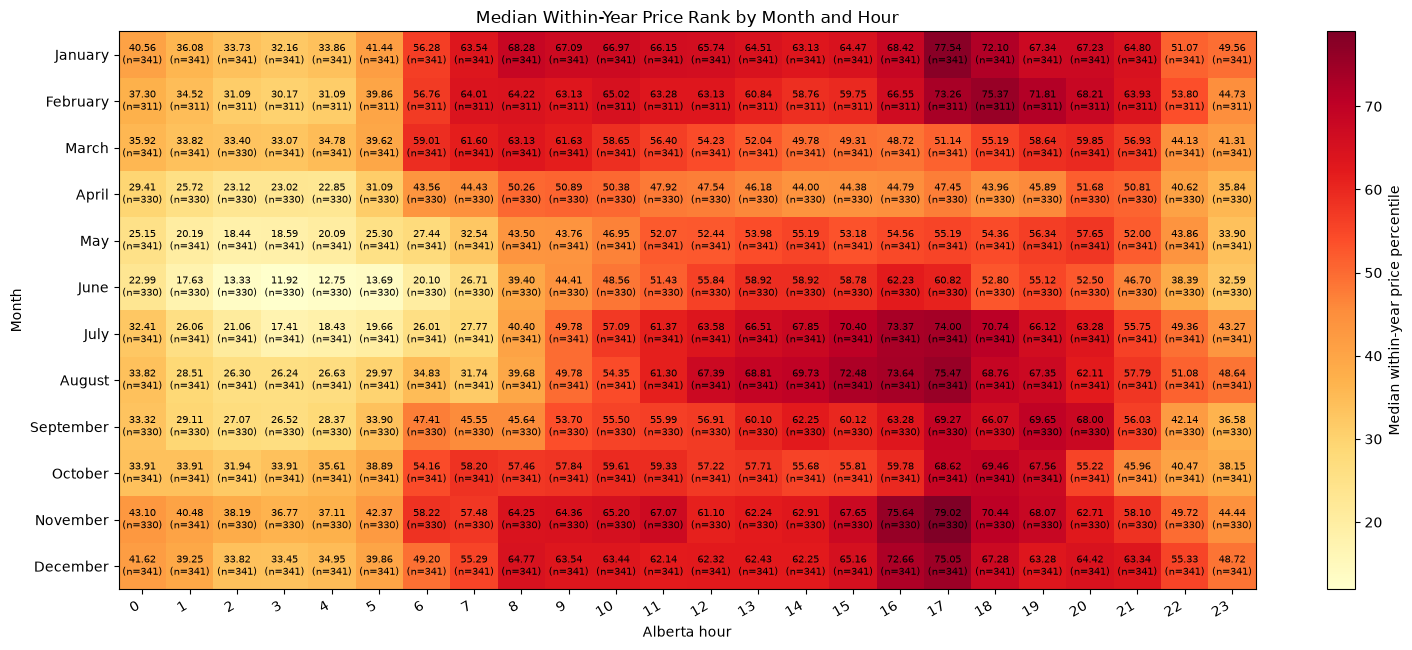

In [8]:
# ---------------------------------------------------------------------
# Compare weekday and monthly intraday structure
# ---------------------------------------------------------------------

calendar_shape_frame = pd.DataFrame({
    "day_name": temporal_features["day_name"],
    "month_name": temporal_features["month_name"],
    "hour_alberta": master["hour_alberta"],
    "price_percentile": temporal_features["price_percentile_within_year"]
})

weekday_hour_summary = (
    calendar_shape_frame.dropna()
    .groupby(["day_name", "hour_alberta"], observed=True)
    .agg(hours=("price_percentile", "size"), median_price_percentile=("price_percentile", "median"))
    .reset_index()
)

weekday_hour_summary["median_price_percentile_pct"] = weekday_hour_summary["median_price_percentile"] * 100

month_hour_summary = (
    calendar_shape_frame.dropna()
    .groupby(["month_name", "hour_alberta"], observed=True)
    .agg(hours=("price_percentile", "size"), median_price_percentile=("price_percentile", "median"))
    .reset_index()
)

month_hour_summary["median_price_percentile_pct"] = month_hour_summary["median_price_percentile"] * 100

plot_annotated_heatmap(
    weekday_hour_summary,
    row_column="day_name",
    column_column="hour_alberta",
    value_column="median_price_percentile_pct",
    count_column="hours",
    row_order=DAY_ORDER,
    column_order=list(range(24)),
    title="Median Within-Year Price Rank by Weekday and Hour",
    row_label="Day of week",
    column_label="Alberta hour",
    colorbar_label="Median within-year price percentile"
)

plot_annotated_heatmap(
    month_hour_summary,
    row_column="month_name",
    column_column="hour_alberta",
    value_column="median_price_percentile_pct",
    count_column="hours",
    row_order=MONTH_ORDER,
    column_order=list(range(24)),
    title="Median Within-Year Price Rank by Month and Hour",
    row_label="Month",
    column_label="Alberta hour",
    colorbar_label="Median within-year price percentile"
)


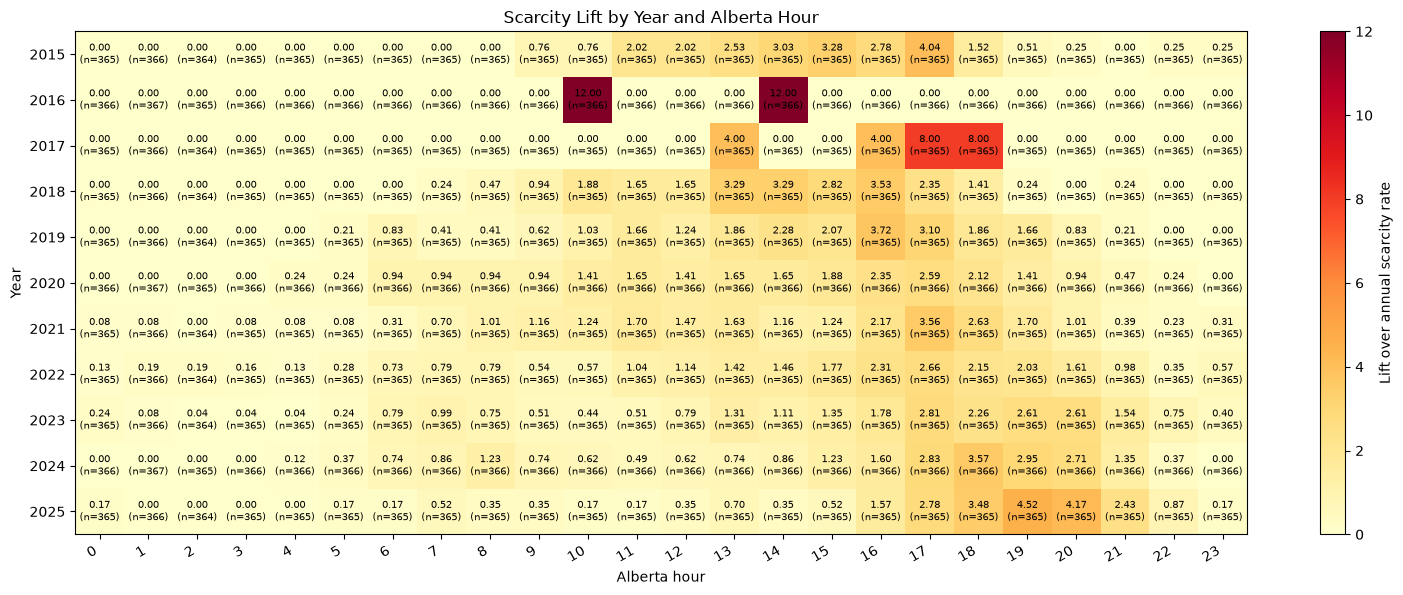

In [9]:
# ---------------------------------------------------------------------
# Test annual stability of hourly scarcity patterns
# ---------------------------------------------------------------------

year_hour_frame = pd.DataFrame({
    "year_alberta": master["year_alberta"],
    "hour_alberta": master["hour_alberta"],
    "scarcity_event": temporal_features["primary_scarcity_event"]
})

annual_scarcity_base = (
    year_hour_frame.groupby("year_alberta")["scarcity_event"]
    .mean()
    .rename("annual_base_rate")
)

year_hour_summary = (
    year_hour_frame.groupby(["year_alberta", "hour_alberta"])
    .agg(
        hours=("scarcity_event", "size"), 
        scarcity_rate=("scarcity_event", "mean")
    ).reset_index().merge(annual_scarcity_base, on="year_alberta", how="left")
)

year_hour_summary["scarcity_lift"] = (
    year_hour_summary["scarcity_rate"]
    / year_hour_summary["annual_base_rate"].replace(0, np.nan)
)

plot_annotated_heatmap(
    year_hour_summary,
    row_column="year_alberta",
    column_column="hour_alberta",
    value_column="scarcity_lift",
    count_column="hours",
    row_order=list(study_years),
    column_order=list(range(24)),
    title="Scarcity Lift by Year and Alberta Hour",
    row_label="Year",
    column_label="Alberta hour",
    colorbar_label="Lift over annual scarcity rate"
)


In [10]:
# ---------------------------------------------------------------------
# Compare holidays with matched non-holiday calendar cells
# ---------------------------------------------------------------------

holiday_frame = pd.DataFrame({
    "year_alberta": master["year_alberta"],
    "month_alberta": master["month_alberta"],
    "day_of_week_alberta": master["day_of_week_alberta"],
    "hour_alberta": master["hour_alberta"],
    "holiday_state": temporal_features["holiday_state"],
    "price_asinh": temporal_features["price_asinh"],
    "pool_price": master["pool_price"],
    "scarcity_event": temporal_features["primary_scarcity_event"]
})

ordinary_baseline = (
    holiday_frame.loc[holiday_frame["holiday_state"].eq("Ordinary day")]
    .groupby(["year_alberta", "month_alberta", "day_of_week_alberta", "hour_alberta"])["price_asinh"]
    .median()
    .rename("matched_price_baseline")
    .reset_index()
)

holiday_frame = holiday_frame.merge(
    ordinary_baseline,
    on=["year_alberta", "month_alberta", "day_of_week_alberta", "hour_alberta"],
    how="left"
)

holiday_frame["matched_price_residual"] = (
    holiday_frame["price_asinh"] - holiday_frame["matched_price_baseline"]
)

holiday_summary = (
    holiday_frame.dropna(subset=["holiday_state", "matched_price_residual"])
    .groupby("holiday_state", observed=True)
    .agg(
        hours=("pool_price", "size"),
        median_pool_price=("pool_price", "median"),
        median_matched_price_residual=("matched_price_residual", "median"),
        scarcity_rate=("scarcity_event", "mean")
    )
    .reindex(HOLIDAY_STATE_ORDER)
)

holiday_summary["scarcity_rate_pct"] = holiday_summary["scarcity_rate"] * 100

display(holiday_summary.round(3))


,hours,median_pool_price,median_matched_price_residual,scarcity_rate,scarcity_rate_pct
holiday_state,,,,,
Ordinary day,88968,32.905,0.000,0.026,2.574
Day before holiday,2472,31.740,-0.013,0.015,1.497
Holiday,2616,31.020,-0.030,0.011,1.070
Day after holiday,2376,32.795,-0.005,0.032,3.157


### 2.1 Calendar results

Typical prices are lowest overnight and highest during the late afternoon, with the maximum median price occurring around hour 17. Upper-tail prices and scarcity frequency are much more concentrated: at hour 17, the 90th-percentile price reaches approximately $335/MWh and the scarcity rate reaches 7.3%. Scarcity therefore occurs in the same broad hours as elevated median prices, but its intraday concentration is considerably stronger.

Weekdays—particularly Monday through Thursday—show persistently elevated price ranks during commercial and evening hours. Winter months exhibit an earlier morning increase and sustained evening pressure, while July and August show stronger afternoon and early-evening prices. Weekend profiles are generally lower, especially during the morning and daytime.

After normalizing by each year’s scarcity base rate, the late-afternoon and evening pattern remains visible across most years. Estimates from 2016 and 2017 are unstable because those years contain very few scarcity observations, but the broader concentration around hours 16–20 is persistent.

After matching on year, month, weekday, and hour, the median holiday price residual is near zero. This suggests little remaining difference in typical prices, but the comparison does not establish that holidays add no information because uncertainty and year-level stability are not tested. The lower holiday scarcity rate and higher day-after rate remain descriptive and should not be interpreted causally because weather, demand, outages, and other operating conditions are not controlled.

## 3. Price persistence

Electricity prices may exhibit short-lived persistence because tight physical conditions, unit commitment, outages, offers, and market responses can span multiple hours.

This section uses a compact set of economically meaningful horizons rather than conducting exhaustive lag selection. It asks:

1. How quickly does price dependence decay?
2. Does a high prior price correspond to higher current scarcity frequency?
3. Is the relationship stable across years and structural regimes?
4. Does daily or weekly recurrence remain after short-horizon persistence weakens?

Formal lag selection belongs in the forecasting notebooks.

,lag_hours,observations,coverage_pct,spearman_price_correlation,top_decile_scarcity_rate,top_decile_scarcity_lift,annual_correlation_25th_percentile,annual_correlation_75th_percentile,positive_annual_correlation_pct
0,1,96431,99.999,0.956,0.217,8.602,0.906,0.935,100.0
1,2,96430,99.998,0.903,0.182,7.205,0.789,0.846,100.0
2,3,96429,99.997,0.857,0.152,6.051,0.682,0.760,100.0
3,6,96426,99.994,0.760,0.097,3.856,0.461,0.526,100.0
4,12,96420,99.988,0.679,0.057,2.274,0.250,0.321,100.0
5,24,96408,99.975,0.758,0.122,4.831,0.491,0.627,100.0
6,48,96384,99.950,0.715,0.089,3.549,0.382,0.508,100.0
7,168,96264,99.826,0.680,0.067,2.655,0.318,0.447,100.0


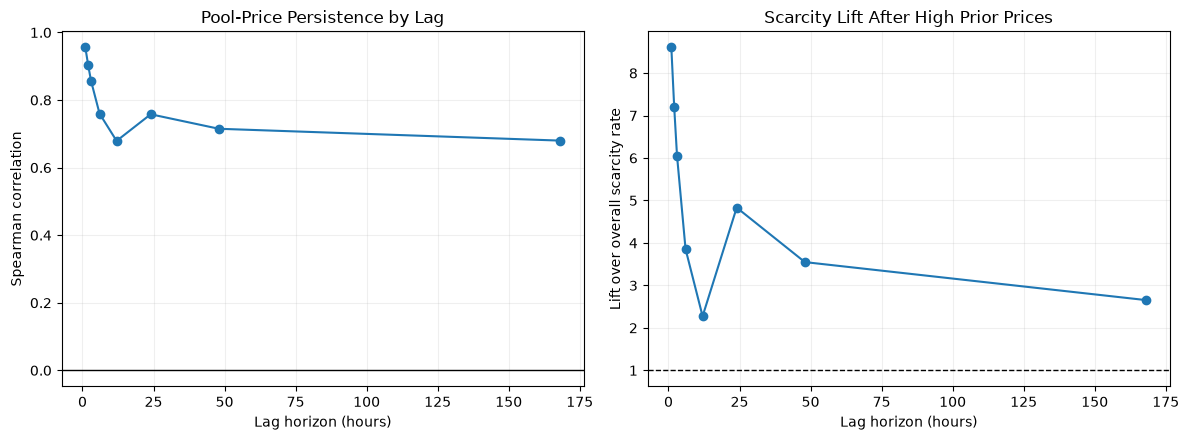

In [11]:
# ---------------------------------------------------------------------
# Screen price persistence across selected lag horizons
# ---------------------------------------------------------------------

lag_screen_rows = []

for horizon in LAG_HORIZONS:
    lag_column = f"pool_price_lag_{horizon}h"

    frame = pd.DataFrame({
        "year_alberta": master["year_alberta"],
        "current_price": master["pool_price"],
        "lagged_price": master[lag_column],
        "scarcity_event": temporal_features["primary_scarcity_event"]
    }).dropna()

    lag_percentile = frame.groupby("year_alberta")["lagged_price"].rank(method="average", pct=True)
    top_decile = lag_percentile.ge(0.90)
    base_rate = frame["scarcity_event"].mean()
    top_decile_rate = frame.loc[top_decile, "scarcity_event"].mean()

    annual_correlations = np.asarray([
        group["lagged_price"].corr(group["current_price"], method="spearman")
        for _, group in frame.groupby("year_alberta")
    ], dtype=float)

    lag_screen_rows.append({
        "lag_hours": horizon,
        "observations": len(frame),
        "coverage_pct": len(frame) / len(master) * 100,
        "spearman_price_correlation": frame["lagged_price"].corr(frame["current_price"], method="spearman"),
        "top_decile_scarcity_rate": top_decile_rate,
        "top_decile_scarcity_lift": top_decile_rate / base_rate if base_rate > 0 else np.nan,
        "annual_correlation_25th_percentile": np.nanquantile(annual_correlations, 0.25),
        "annual_correlation_75th_percentile": np.nanquantile(annual_correlations, 0.75),
        "positive_annual_correlation_pct": np.mean(annual_correlations > 0) * 100
    })

lag_screen = pd.DataFrame(lag_screen_rows)
display(lag_screen.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(lag_screen["lag_hours"], lag_screen["spearman_price_correlation"], marker="o")
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("Pool-Price Persistence by Lag")
axes[0].set_xlabel("Lag horizon (hours)")
axes[0].set_ylabel("Spearman correlation")
axes[0].grid(alpha=0.20)

axes[1].plot(lag_screen["lag_hours"], lag_screen["top_decile_scarcity_lift"], marker="o")
axes[1].axhline(1, color="black", linewidth=1, linestyle="--")
axes[1].set_title("Scarcity Lift After High Prior Prices")
axes[1].set_xlabel("Lag horizon (hours)")
axes[1].set_ylabel("Lift over overall scarcity rate")
axes[1].grid(alpha=0.20)

plt.tight_layout()
plt.show()

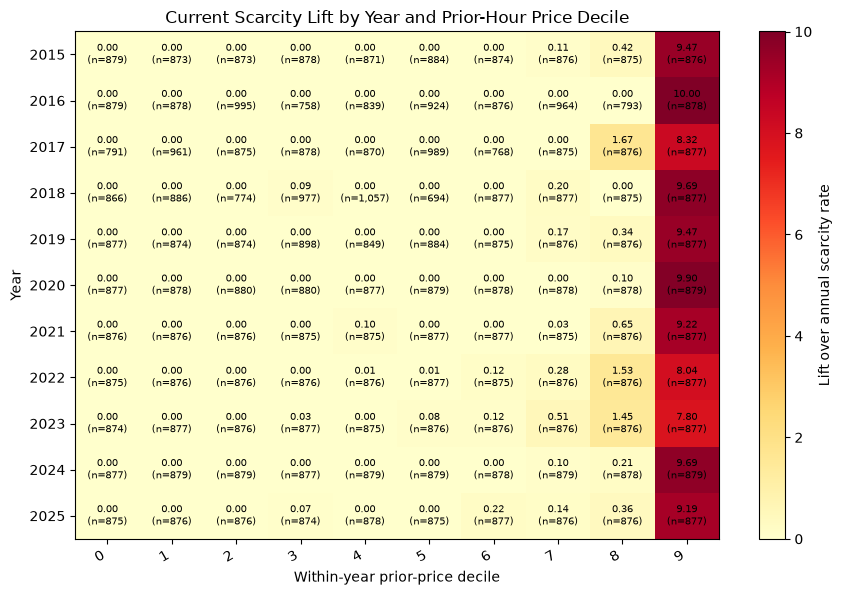

In [12]:
# ---------------------------------------------------------------------
# Test annual stability of the one-hour lag relationship
# ---------------------------------------------------------------------

prior_price_year_deciles = build_year_decile_summary(
    master["pool_price_lag_1h"],
    temporal_features["primary_scarcity_event"]
)

plot_annotated_heatmap(
    prior_price_year_deciles,
    row_column="year_alberta",
    column_column="decile",
    value_column="event_lift",
    count_column="hours",
    row_order=list(study_years),
    column_order=list(range(10)),
    title="Current Scarcity Lift by Year and Prior-Hour Price Decile",
    row_label="Year",
    column_label="Within-year prior-price decile",
    colorbar_label="Lift over annual scarcity rate"
)


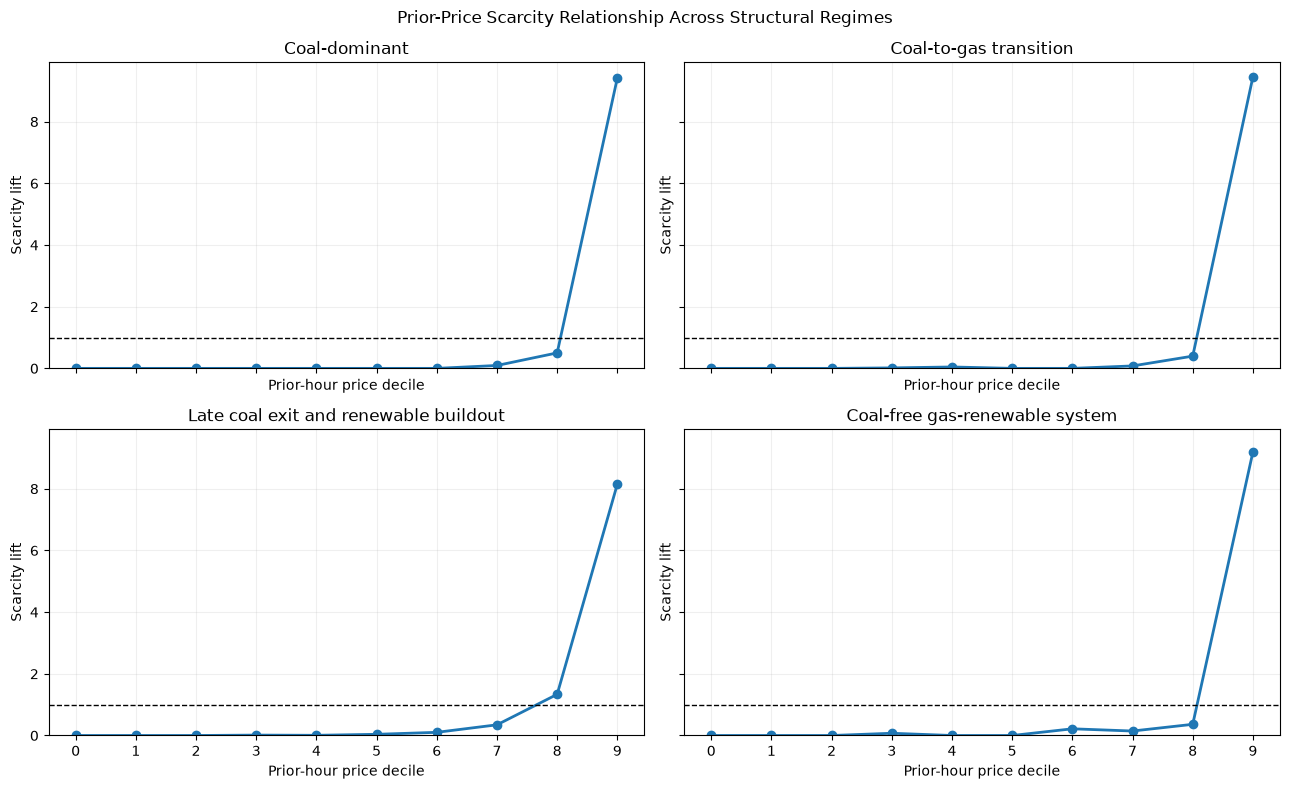

In [13]:
# ---------------------------------------------------------------------
# Compare prior-price deciles across structural regimes
# ---------------------------------------------------------------------

regime_prior_price = pd.DataFrame({
    "structural_regime": structural_regime,
    "prior_price_decile": temporal_features["prior_price_decile"],
    "current_price": master["pool_price"],
    "scarcity_event": temporal_features["primary_scarcity_event"]
}).dropna()

regime_base_rate = (
    regime_prior_price.groupby("structural_regime", observed=True)["scarcity_event"]
    .mean().rename("regime_base_rate")
)

regime_prior_price_summary = (
    regime_prior_price.groupby(["structural_regime", "prior_price_decile"], observed=True)
    .agg(
        hours=("scarcity_event", "size"),
        current_scarcity_rate=("scarcity_event", "mean"),
        median_current_price=("current_price", "median")
    )
    .reset_index()
    .merge(regime_base_rate, on="structural_regime", how="left")
)

regime_prior_price_summary["scarcity_lift"] = (
    regime_prior_price_summary["current_scarcity_rate"]
    / regime_prior_price_summary["regime_base_rate"].replace(0, np.nan)
)

maximum_lift = regime_prior_price_summary["scarcity_lift"].max()

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True, sharey=True)

for axis, regime in zip(axes.flatten(), STRUCTURAL_REGIME_ORDER):
    plot_data = (
        regime_prior_price_summary.loc[
            regime_prior_price_summary["structural_regime"].eq(regime)
        ].set_index("prior_price_decile").reindex(range(10))
    )

    axis.plot(plot_data.index, plot_data["scarcity_lift"], marker="o", linewidth=2)
    axis.axhline(1, color="black", linewidth=1, linestyle="--")
    axis.set_title(regime)
    axis.set_xlabel("Prior-hour price decile")
    axis.set_ylabel("Scarcity lift")
    axis.set_xticks(range(10))
    axis.set_ylim(0, maximum_lift * 1.05)
    axis.grid(alpha=0.20)

fig.suptitle("Prior-Price Scarcity Relationship Across Structural Regimes")
plt.tight_layout()
plt.show()


In [14]:
# ---------------------------------------------------------------------
# Test weekly-lag sensitivity to the high-scarcity 2022-2023 period
# ---------------------------------------------------------------------

weekly_sensitivity_frame = pd.DataFrame({
    "year_alberta": master["year_alberta"],
    "weekly_lagged_price": master["pool_price_lag_168h"],
    "scarcity_event": temporal_features["primary_scarcity_event"],
}).dropna()

weekly_sensitivity_rows = []

for sample_name, excluded_years in [
    ("Complete sample", []),
    ("Excluding 2022-2023", [2022, 2023]),
]:
    sample = weekly_sensitivity_frame.loc[
        ~weekly_sensitivity_frame["year_alberta"].isin(excluded_years)
    ].copy()

    weekly_percentile = (
        sample.groupby("year_alberta")["weekly_lagged_price"]
        .rank(method="average", pct=True)
    )
    top_decile = weekly_percentile.ge(0.90)
    base_rate = sample["scarcity_event"].mean()
    top_decile_rate = sample.loc[top_decile, "scarcity_event"].mean()

    weekly_sensitivity_rows.append({
        "sample": sample_name,
        "years": sample["year_alberta"].nunique(),
        "hours": len(sample),
        "scarcity_base_rate": base_rate,
        "weekly_top_decile_scarcity_rate": top_decile_rate,
        "weekly_top_decile_scarcity_lift": (
            top_decile_rate / base_rate if base_rate > 0 else np.nan
        ),
    })

weekly_lag_sensitivity = pd.DataFrame(weekly_sensitivity_rows)
display(weekly_lag_sensitivity.round(3))


,sample,years,hours,scarcity_base_rate,weekly_top_decile_scarcity_rate,weekly_top_decile_scarcity_lift
0,Complete sample,11,96264,0.025,0.067,2.655
1,Excluding 2022-2023,9,78744,0.014,0.036,2.696


### 3.1 Lag results

Pool prices exhibit strong short-term persistence across all hours—not only scarcity hours. Spearman correlation falls from 0.956 at one hour to 0.857 at three hours, 0.760 at six hours, and 0.679 at twelve hours. It rebounds to 0.758 at 24 hours before weakening to 0.680 at one week, indicating recurring daily and weekly structure in addition to immediate price continuity.

High prior prices are also associated with elevated current scarcity. When the prior-hour price is in its within-year top decile, the current scarcity rate reaches 21.7%, or 8.6 times the baseline. The lift declines with horizon, falling to 2.3 at twelve hours, rebounding to 4.8 at 24 hours, and remaining at 2.7 after one week.

Pool prices are highly persistent across all hours, but scarcity episodes usually last only one to three hours. Longer-horizon lag relationships therefore reflect recurring calendar patterns and persistent market conditions—not continuous scarcity lasting for days or weeks.

The 168-hour relationship survives removal of 2022–2023. Excluding those years reduces the weekly top-decile scarcity rate from 6.7% to 3.6%, but relative lift remains near 2.7 because the underlying scarcity rate also declines. Its absolute forecasting value is therefore much smaller outside the unusually high-scarcity conditions of 2022–2023.

The prior-hour relationship is positive in every year, and its top-decile scarcity lift remains approximately 7.8–10.0 across the structural-regime groupings. The coal-free gas-renewable grouping currently contains only 2025, so it is an initial structural comparison rather than evidence of within-regime stability. Lagged price is therefore a strong candidate for short-horizon forecast testing, but it should be interpreted as a summary of market memory and persistent underlying conditions rather than an independent causal mechanism.

## 4. Volatility clustering

Price volatility may persist because market stress and uncertainty can extend across adjacent hours.

The prior 24-hour volatility field excludes the current hour and is therefore distinct from the current absolute price change. This section asks:

1. Does high prior volatility correspond to larger current price changes?
2. Does it correspond to elevated scarcity frequency?
3. Is the relationship stable across years?
4. How long do high-volatility states persist?
5. Does lagged absolute price movement retain information over multiple horizons?

,hours,median_prior_volatility,median_absolute_price_change,price_change_90th_percentile,scarcity_rate,scarcity_lift
volatility_decile,,,,,,
0,9634,2.124,0.94,6.900,0.000,0.012
1,9643,2.890,1.19,9.198,0.000,0.016
2,9644,3.777,1.37,11.787,0.001,0.033
3,9641,5.128,1.63,16.240,0.002,0.078
4,9642,6.943,1.92,22.009,0.004,0.177
5,9645,9.773,2.26,33.860,0.009,0.350
6,9641,15.464,2.61,43.780,0.013,0.502
7,9645,24.878,3.28,74.580,0.032,1.280
8,9642,65.684,4.26,126.969,0.056,2.227


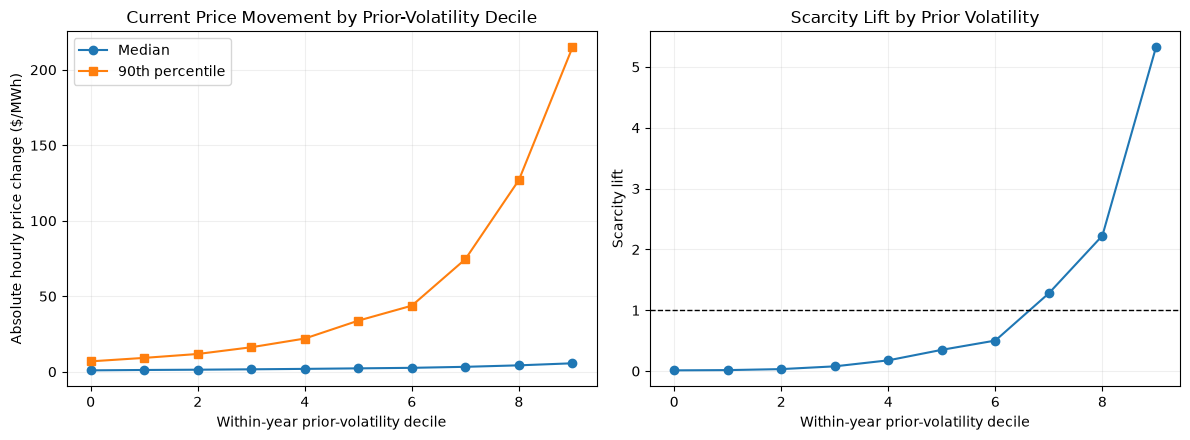

In [15]:
# ---------------------------------------------------------------------
# Compare current outcomes across prior-volatility deciles
# ---------------------------------------------------------------------

volatility_frame = pd.DataFrame({
    "volatility_decile": temporal_features["prior_volatility_decile"],
    "prior_volatility": temporal_features["prior_volatility_24h"],
    "absolute_price_change": temporal_features["absolute_price_change_1h"],
    "scarcity_event": temporal_features["primary_scarcity_event"]
}).dropna()

volatility_base_rate = volatility_frame["scarcity_event"].mean()

volatility_decile_summary = (
    volatility_frame.groupby("volatility_decile", observed=True)
    .agg(
        hours=("scarcity_event", "size"),
        median_prior_volatility=("prior_volatility", "median"),
        median_absolute_price_change=("absolute_price_change", "median"),
        price_change_90th_percentile=("absolute_price_change", lambda series: series.quantile(0.90)),
        scarcity_rate=("scarcity_event", "mean")
    )
)

volatility_decile_summary["scarcity_lift"] = volatility_decile_summary["scarcity_rate"] / volatility_base_rate

display(volatility_decile_summary.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(
    volatility_decile_summary.index,
    volatility_decile_summary["median_absolute_price_change"],
    marker="o", label="Median"
)
axes[0].plot(
    volatility_decile_summary.index,
    volatility_decile_summary["price_change_90th_percentile"],
    marker="s", label="90th percentile"
)
axes[0].set_title("Current Price Movement by Prior-Volatility Decile")
axes[0].set_xlabel("Within-year prior-volatility decile")
axes[0].set_ylabel("Absolute hourly price change ($/MWh)")
axes[0].grid(alpha=0.20)
axes[0].legend()

axes[1].plot(
    volatility_decile_summary.index,
    volatility_decile_summary["scarcity_lift"],
    marker="o"
)
axes[1].axhline(1, color="black", linewidth=1, linestyle="--")
axes[1].set_title("Scarcity Lift by Prior Volatility")
axes[1].set_xlabel("Within-year prior-volatility decile")
axes[1].set_ylabel("Scarcity lift")
axes[1].grid(alpha=0.20)

plt.tight_layout()
plt.show()

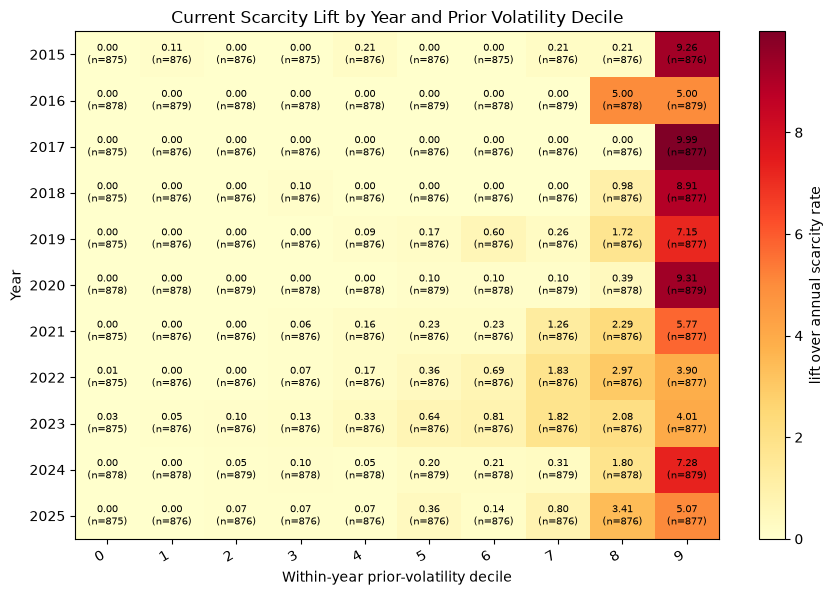

In [16]:
# ---------------------------------------------------------------------
# Test annual stability of prior volatility
# ---------------------------------------------------------------------

volatility_year_deciles = (
    build_year_decile_summary(
        temporal_features["prior_volatility_24h"],
        temporal_features["primary_scarcity_event"],
    )
)

plot_annotated_heatmap(
    volatility_year_deciles,
    row_column = "year_alberta",
    column_column = "decile",
    value_column = "event_lift",
    count_column = "hours",
    row_order = list(study_years),
    column_order = list(range(10)),
    title = (
        "Current Scarcity Lift by Year "
        "and Prior Volatility Decile"
    ),
    row_label = "Year",
    column_label = "Within-year prior-volatility decile",
    colorbar_label = ("lift over annual scarcity rate"),
)

In [17]:
# ---------------------------------------------------------------------
# Screen persistence in absolute price changes
# ---------------------------------------------------------------------

absolute_change = temporal_features["absolute_price_change_1h"]
absolute_change_rows = []

for horizon in LAG_HORIZONS:
    lagged_absolute_change = absolute_change.shift(horizon)

    frame = pd.DataFrame({
        "current_absolute_change": absolute_change,
        "lagged_absolute_change": lagged_absolute_change
    }).dropna()

    annual_correlations = []

    for year, year_index in master.groupby("year_alberta").groups.items():
        annual_frame = pd.DataFrame({
            "current_absolute_change": absolute_change.loc[year_index],
            "lagged_absolute_change": lagged_absolute_change.loc[year_index]
        }).dropna()

        if len(annual_frame) < 2:
            continue

        annual_correlations.append(
            annual_frame["current_absolute_change"].corr(
                annual_frame["lagged_absolute_change"], method="spearman"
            )
        )

    absolute_change_rows.append({
        "lag_hours": horizon,
        "observations": len(frame),
        "spearman_absolute_change_correlation": frame["current_absolute_change"].corr(
            frame["lagged_absolute_change"], method="spearman"
        ),
        "median_annual_correlation": np.nanmedian(annual_correlations),
        "positive_annual_correlation_pct": np.mean(np.asarray(annual_correlations) > 0) * 100
    })

absolute_change_persistence = pd.DataFrame(absolute_change_rows)

display(absolute_change_persistence.round(3))



,lag_hours,observations,spearman_absolute_change_correlation,median_annual_correlation,positive_annual_correlation_pct
0,1,96430,0.632,0.540,100.0
1,2,96429,0.512,0.374,100.0
2,3,96428,0.451,0.283,100.0
3,6,96425,0.358,0.145,100.0
4,12,96419,0.323,0.106,100.0
5,24,96407,0.405,0.216,100.0
6,48,96383,0.359,0.157,100.0
7,168,96263,0.350,0.142,100.0


,start,end,duration_hours,maximum_prior_volatility,maximum_absolute_price_change,scarcity_hours
episode_id,,,,,,
12.0,2015-06-22 12:00:00-06:00,2015-07-01 17:00:00-06:00,222,430.96,894.40,41
158.0,2020-01-12 17:00:00-07:00,2020-01-18 18:00:00-07:00,146,461.70,663.08,68
219.0,2022-08-15 14:00:00-06:00,2022-08-20 17:00:00-06:00,124,388.85,713.18,45
223.0,2022-08-30 15:00:00-06:00,2022-09-04 16:00:00-06:00,122,440.84,746.82,42
167.0,2020-07-27 17:00:00-06:00,2020-08-01 16:00:00-06:00,120,315.53,570.26,16
285.0,2024-01-11 19:00:00-07:00,2024-01-16 12:00:00-07:00,114,382.71,737.53,59
183.0,2021-02-08 06:00:00-07:00,2021-02-12 19:00:00-07:00,110,348.36,537.38,41
264.0,2023-06-05 14:00:00-06:00,2023-06-09 21:00:00-06:00,104,445.07,560.25,45
222.0,2022-08-22 14:00:00-06:00,2022-08-26 19:00:00-06:00,102,395.96,571.50,38


,duration_hours
count,343.00
mean,28.14
std,24.96
min,1.00
50%,24.00
75%,29.00
90%,52.00
95%,73.00
99%,121.16
max,222.00


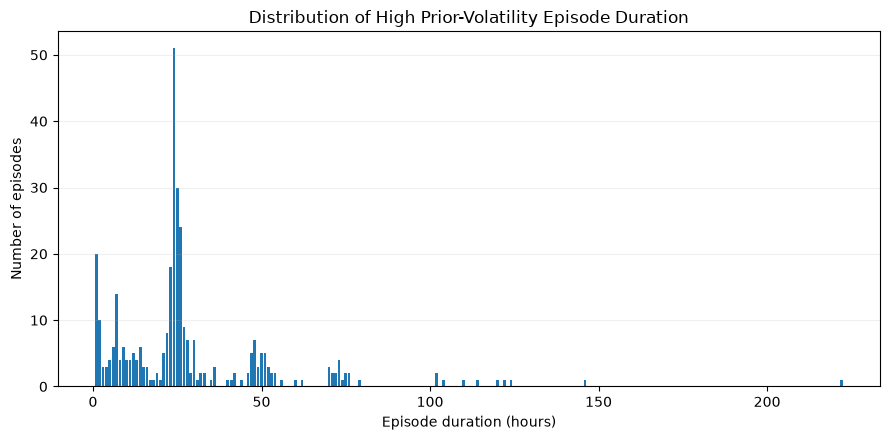

In [18]:
# ---------------------------------------------------------------------
# Construct and summarize high-volatility episodes
# ---------------------------------------------------------------------

high_prior_volatility = temporal_features["prior_volatility_percentile_within_year"].ge(0.90)
high_volatility_episode_id = build_episode_id(high_prior_volatility)

high_volatility_hourly = pd.DataFrame({
    "episode_id": high_volatility_episode_id,
    "timestamp_alberta": master["timestamp_alberta"],
    "prior_volatility": temporal_features["prior_volatility_24h"],
    "absolute_price_change": temporal_features["absolute_price_change_1h"],
    "scarcity_event": temporal_features["primary_scarcity_event"]
}).dropna(subset=["episode_id"])

high_volatility_episodes = (
    high_volatility_hourly.groupby("episode_id")
    .agg(
        start=("timestamp_alberta", "min"),
        end=("timestamp_alberta", "max"),
        duration_hours=("timestamp_alberta", "size"),
        maximum_prior_volatility=("prior_volatility", "max"),
        maximum_absolute_price_change=("absolute_price_change", "max"),
        scarcity_hours=("scarcity_event", "sum")
    )
    .sort_values(["duration_hours", "maximum_prior_volatility"], ascending=False)
)

high_volatility_episode_preview = high_volatility_episodes.head(20).copy()
numeric_preview_columns = high_volatility_episode_preview.select_dtypes(
    include="number"
).columns
high_volatility_episode_preview[numeric_preview_columns] = (
    high_volatility_episode_preview[numeric_preview_columns].round(2)
)
display(high_volatility_episode_preview)

display(
    high_volatility_episodes["duration_hours"]
    .describe(percentiles=[0.50, 0.75, 0.90, 0.95, 0.99])
    .to_frame()
    .round(2)
)

fig, ax = plt.subplots(figsize=(9, 4.5))

duration_counts = high_volatility_episodes["duration_hours"].value_counts().sort_index()

ax.bar(duration_counts.index, duration_counts.values)
ax.set_title("Distribution of High Prior-Volatility Episode Duration")
ax.set_xlabel("Episode duration (hours)")
ax.set_ylabel("Number of episodes")
ax.grid(axis="y", alpha=0.20)

plt.tight_layout()
plt.show()


### 4.1 Volatility results

Larger price movements consistently follow high-volatility histories. Median absolute hourly price change rises from $0.94/MWh in the lowest prior-volatility decile to $5.62/MWh in the highest, while the 90th percentile increases much more sharply—from $6.91/MWh to $214.84/MWh. The relationship is concentrated in the upper tail: scarcity lift remains below one through decile 6, rises to 1.3 in decile 7, reaches 2.2 in decile 8, and climbs to 5.3 in decile 9.

High prior volatility identifies elevated scarcity in every year, but less consistently than the single prior-hour price. Top-decile volatility lift ranges from approximately 3.9 to 10.0 across years, compared with roughly 7.8–10.0 for the highest prior-price decile. Prior volatility therefore provides broader information about unstable market conditions, while the most recent price is the stronger immediate scarcity signal.

High-volatility conditions are persistent rather than isolated. Across 343 episodes, median duration is 24 hours, 10% last at least 52 hours, and the longest continues for 222 hours. Part of this persistence is mechanical because the rolling-volatility measure retains large historical price changes within its calculation window even after the original shock has passed.

Absolute-price-change correlation decays from 0.632 at one hour to 0.323 at twelve hours, then rebounds to 0.405 at 24 hours and remains positive at weekly horizons. The direction is positive in every year, although median within-year correlations are considerably smaller at longer horizons. This suggests strong immediate volatility clustering together with weaker recurring daily and persistent market structure.

Prior rolling volatility is therefore a candidate for forecast testing, especially for elevated tail risk. Its incremental value beyond the prior-hour price remains unresolved, and it should not be interpreted as an independent physical or behavioural cause of subsequent volatility.

## 5. Price-state transitions

This section examines whether prices transition gradually between states or jump directly from ordinary conditions into scarcity.

The analysis covers:

- one-hour transition probabilities between price states;
- scarcity continuation as the prior event run length increases;
- the duration of consecutive scarcity episodes; and
- price and volatility profiles around event onset.

These are descriptive transition statistics. Notebook 2 remains responsible for the physical conditions associated with scarcity.


current_price_state,Below $100,$100–$299,$300–$499,$500–$899,$900+
prior_price_state,,,,,
Below $100,83920,2083,261,107,3
$100–$299,2061,3055,594,292,8
$300–$499,275,542,452,336,12
$500–$899,117,320,294,1147,130
$900+,1,10,16,126,269


current_price_state,Below $100,$100–$299,$300–$499,$500–$899,$900+
prior_price_state,,,,,
Below $100,97.16,2.41,0.30,0.12,0.00
$100–$299,34.29,50.83,9.88,4.86,0.13
$300–$499,17.01,33.52,27.95,20.78,0.74
$500–$899,5.83,15.94,14.64,57.12,6.47
$900+,0.24,2.37,3.79,29.86,63.74


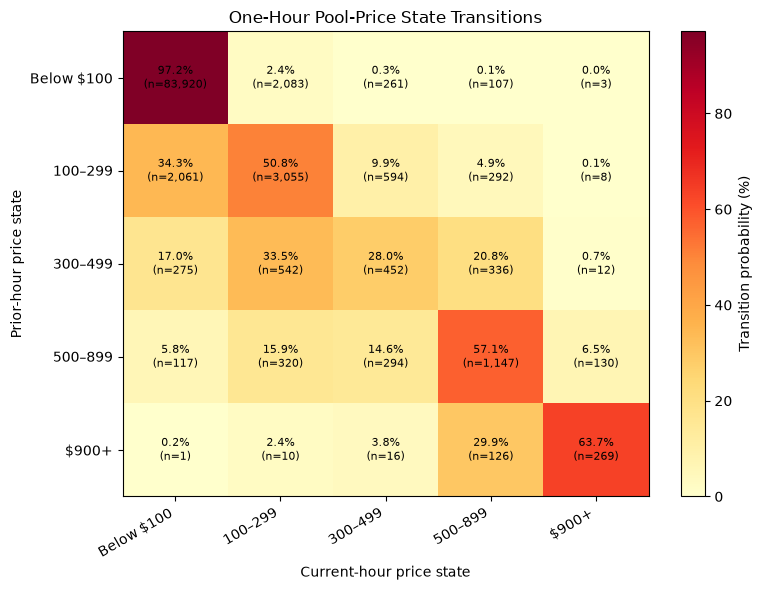

In [19]:
# ---------------------------------------------------------------------
# Calculate one-hour price-state transition probabilities
# ---------------------------------------------------------------------

transition_frame = pd.DataFrame({
    "prior_price_state": temporal_features["prior_price_state"],
    "current_price_state": temporal_features["price_state"],
}).dropna()

transition_counts = pd.crosstab(
    transition_frame["prior_price_state"],
    transition_frame["current_price_state"],
).reindex(
    index = PRICE_STATE_ORDER,
    columns = PRICE_STATE_ORDER,
    fill_value = 0,
)

transition_probabilities = (
    transition_counts.div(transition_counts.sum(axis = 1), axis = 0) * 100
)

display(transition_counts)
display(transition_probabilities.round(2))

fig, ax = plt.subplots(figsize=(8, 6))

image = ax.imshow(
    transition_probabilities,
    aspect="auto",
    cmap="YlOrRd",
    vmin=0,
)

ax.set_xticks(range(len(PRICE_STATE_ORDER)))
ax.set_xticklabels(
    PRICE_STATE_ORDER,
    rotation=30,
    ha="right",
)

ax.set_yticks(range(len(PRICE_STATE_ORDER)))
ax.set_yticklabels(PRICE_STATE_ORDER)

for row in range(
    transition_probabilities.shape[0]
):
    for column in range(
        transition_probabilities.shape[1]
    ):
        probability = (
            transition_probabilities.iloc[row, column]
        )
        count = transition_counts.iloc[row, column]

        if count > 0:
            ax.text(
                column,
                row,
                f"{probability:.1f}%\n"
                f"(n={count:,.0f})",
                ha="center",
                va="center",
                fontsize=8,
            )

ax.set_title("One-Hour Pool-Price State Transitions")
ax.set_xlabel("Current-hour price state")
ax.set_ylabel("Prior-hour price state")

fig.colorbar(
    image,
    ax=ax,
    label="Transition probability (%)",
)

plt.tight_layout()
plt.show()

In [20]:
# ---------------------------------------------------------------------
# Measure scarcity continuation by prior event run length
# ---------------------------------------------------------------------

primary_event = (temporal_features["primary_scarcity_event"])

event_block = (primary_event.ne(primary_event.shift(fill_value = False)).cumsum())

current_event_run_length = (primary_event.groupby(event_block).cumsum().where(primary_event, 0))

prior_event_run_length = (current_event_run_length.shift(1).fillna(0))

PRIOR_RUN_STATE_ORDER = (
    "No prior scarcity", 
    "1 prior hour", 
    "2 prior hours", 
    "3-5 prior hours",
    "6+ prior hours",
)

prior_run_state = pd.cut(
    prior_event_run_length, bins = [
        -1, 
        0, 
        1, 
        2, 
        5, 
        np.inf,
    ], labels = PRIOR_RUN_STATE_ORDER,
)

continuation_summary = (
    pd.DataFrame({
        "prior_run_state": prior_run_state,
        "current_scarcity": primary_event,
    }).dropna().groupby("prior_run_state", observed = True).agg(
        hours = ("current_scarcity", "size"),
        current_scarcity_rate = ("current_scarcity", "mean")
    ).reindex(PRIOR_RUN_STATE_ORDER)
)

continuation_summary["current_scarcity_rate_pct"] = (
    continuation_summary["current_scarcity_rate"] * 100
)

display(continuation_summary.round(2))

,hours,current_scarcity_rate,current_scarcity_rate_pct
prior_run_state,,,
No prior scarcity,94002,0.01,0.81
1 prior hour,758,0.60,59.76
2 prior hours,453,0.70,70.42
3-5 prior hours,682,0.71,70.67
6+ prior hours,537,0.78,77.84


In [21]:
# ---------------------------------------------------------------------
# Summarize consecutive scarcity episodes
# ---------------------------------------------------------------------

scarcity_episode_id = (build_episode_id(primary_event))

scarcity_episodes_hourly = pd.DataFrame({
    "episode_id": scarcity_episode_id,
    "timestamp_alberta": master["timestamp_alberta"],
    "pool_price": master["pool_price"],
    "prior_volatility": temporal_features["prior_volatility_24h"],
}).dropna(subset = ["episode_id"])

scarcity_episodes = (
    scarcity_episodes_hourly.groupby("episode_id").agg(
        start = ("timestamp_alberta", "min"),
        end = ("timestamp_alberta", "max"),
        duration_hours = ("timestamp_alberta", "size"),
        average_pool_price = ("pool_price", "mean"),
        maximum_pool_price = ("pool_price", "max"),
        prior_volatility_at_onset = ("prior_volatility", "first"),
    ).sort_values(["duration_hours", "maximum_pool_price"], ascending = False)
)

display(scarcity_episodes["duration_hours"].describe(percentiles = [0.50, 0.75, 0.90, 0.95, 0.99]).to_frame().round(2))

,duration_hours
count,758.00
mean,3.21
std,3.27
min,1.00
50%,2.00
75%,4.00
90%,8.00
95%,10.00
99%,17.00
max,25.00


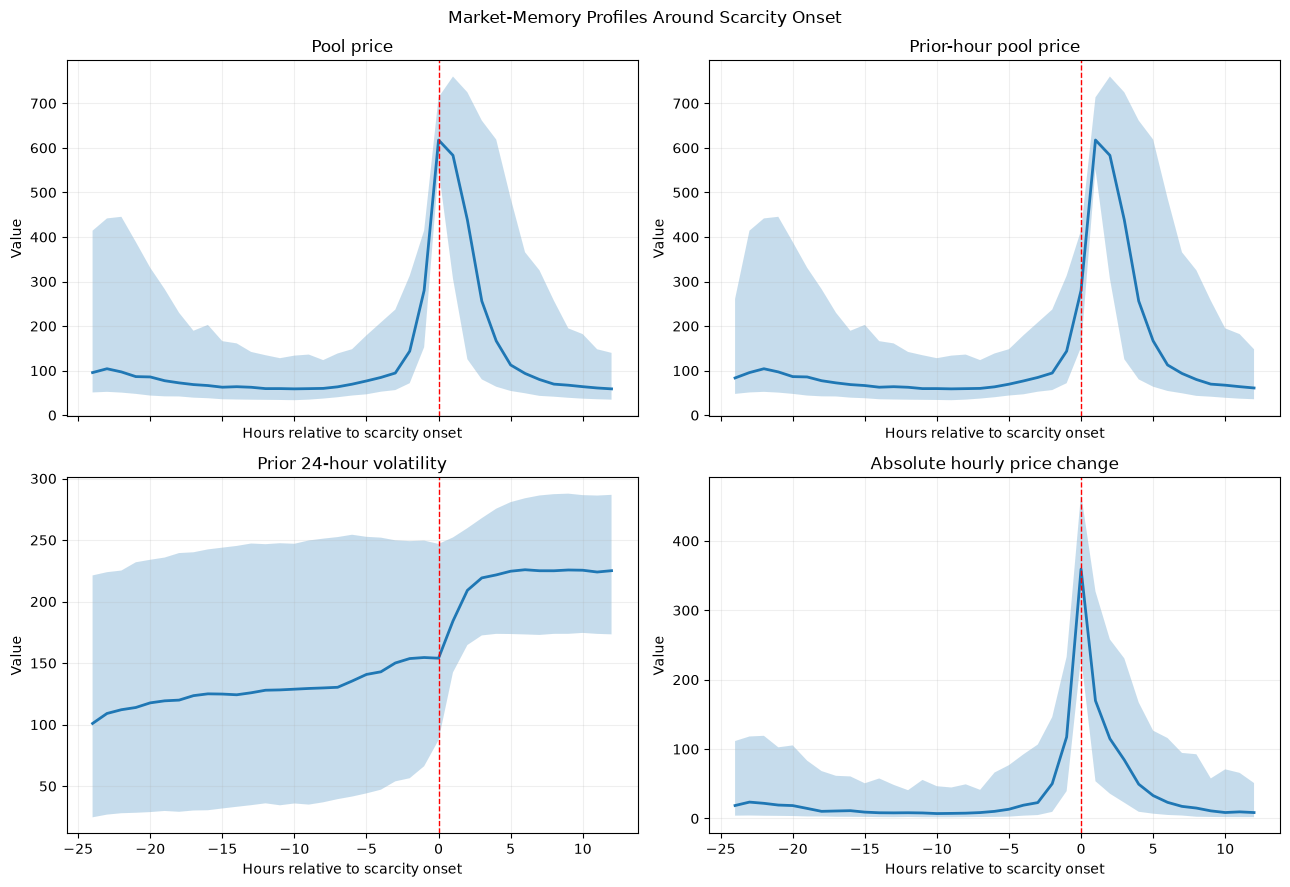

In [22]:
# ---------------------------------------------------------------------
# Aligned market-memory variables around scarcity onset
# ---------------------------------------------------------------------

EVENT_WINDOW_START, EVENT_WINDOW_END = -24, 12

scarcity_onset = primary_event & ~primary_event.shift(fill_value=False)
onset_positions = np.flatnonzero(scarcity_onset.to_numpy())

aligned_variables = {
    "Pool price": master["pool_price"],
    "Prior-hour pool price": master["pool_price_lag_1h"],
    "Prior 24-hour volatility": temporal_features["prior_volatility_24h"],
    "Absolute hourly price change": temporal_features["absolute_price_change_1h"],
}

aligned_rows = []

for episode_number, onset_position in enumerate(onset_positions, 1):
    start_position, end_position = onset_position + EVENT_WINDOW_START, onset_position + EVENT_WINDOW_END
    if start_position < 0 or end_position >= len(master): continue

    aligned_block = pd.DataFrame({
        name: values.iloc[start_position:end_position + 1].to_numpy()
        for name, values in aligned_variables.items()
    })
    aligned_block["episode_number"] = episode_number
    aligned_block["relative_hour"] = np.arange(EVENT_WINDOW_START, EVENT_WINDOW_END + 1)
    aligned_rows.append(aligned_block)

event_aligned = pd.concat(aligned_rows, ignore_index=True)

event_aligned_long = event_aligned.melt(
    id_vars=["episode_number", "relative_hour"],
    var_name="variable", value_name="value"
)

event_aligned_profile = (
    event_aligned_long.groupby(["variable", "relative_hour"])["value"]
    .agg(
        median="median",
        q25=lambda s: s.quantile(.25),
        q75=lambda s: s.quantile(.75),
        observations="count"
    ).reset_index()
)

fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True)

for ax, variable in zip(axes.flatten(), aligned_variables):
    plot_data = event_aligned_profile[event_aligned_profile["variable"].eq(variable)]

    ax.plot(plot_data["relative_hour"], plot_data["median"], linewidth=2)
    ax.fill_between(plot_data["relative_hour"], plot_data["q25"], plot_data["q75"], alpha=.25)
    ax.axvline(0, color="red", linestyle="--", linewidth=1)
    ax.set(title=variable, xlabel="Hours relative to scarcity onset", ylabel="Value")
    ax.grid(alpha=.20)

fig.suptitle("Market-Memory Profiles Around Scarcity Onset")
plt.tight_layout()
plt.show()

### 5.1 Transition results

Hourly price states are strongly persistent, particularly at the extremes. Prices below $100/MWh remain there 97.2% of the time. Once scarcity begins, a price between $500 and $899 remains above $500 in the next hour 63.6% of the time, while a price above $900 remains in scarcity 93.6% of the time.

Most scarcity events emerge from already elevated prices rather than abrupt jumps from ordinary conditions. Of the 758 event onsets, approximately 46% begin after a prior price of $300–$499, 40% after $100–$299, and only 15% after a price below $100. The probability of continuation then rises with event age: it is 59.8% after one scarcity hour, approximately 70% after two to five hours, and 77.8% after six or more hours.

Scarcity events are usually short but not predominantly isolated. Their median duration is two hours and mean duration is 3.2 hours; 75% end within four hours and 90% within eight. Approximately 40% last only one hour, while the remainder continue for at least a second hour. A small persistence tail extends to a maximum of 25 hours.

Prior 24-hour volatility is already rising before onset, indicating that scarcity often develops within an increasingly unstable price environment. Price and absolute hourly movement spike sharply at onset, then decline substantially over the following several hours and move closer to ordinary levels within roughly 6–12 hours. Rolling volatility remains elevated longer because the onset shock continues to occupy the trailing 24-hour calculation window.

Event-aligned price and volatility profiles therefore describe a common temporal signature: elevated prices and instability often precede scarcity, continuation becomes more likely once an event survives its first hour, and price levels normalize faster than trailing volatility. These patterns represent market memory and event dynamics; they do not identify the physical cause of individual scarcity episodes.

## 6. Calendar and price memory

Calendar structure and price history may overlap. A high prior price could be more informative during some hours simply because those hours already have higher scarcity base rates.

This section evaluates the prior-price-state relationship after conditioning on year and hour. Each cell reports the median annual lift over that year and hour's scarcity base rate.

Annual cells require at least 10 observations and a non-zero year-hour scarcity base rate. Pooled cells require at least 100 observations, and stability is reported only when at least five years qualify.

,prior_price_state,hour_alberta,pooled_hours,pooled_scarcity_rate,median_annual_hour_adjusted_lift,years_qualifying,supported_lift
0,Below $100,0,3686,0.000,0.000,4.0,NaN
1,Below $100,1,3803,0.000,0.000,3.0,NaN
2,Below $100,2,3830,0.000,0.000,2.0,NaN
3,Below $100,3,3867,0.000,0.000,3.0,NaN
4,Below $100,4,3875,0.000,0.000,5.0,0.0
...,...,...,...,...,...,...,...
111,$900+,19,51,0.922,5.703,1.0,NaN
112,$900+,20,47,0.957,10.240,2.0,NaN
113,$900+,21,32,0.875,9.359,1.0,NaN
114,$900+,22,13,0.769,NaN,NaN,NaN


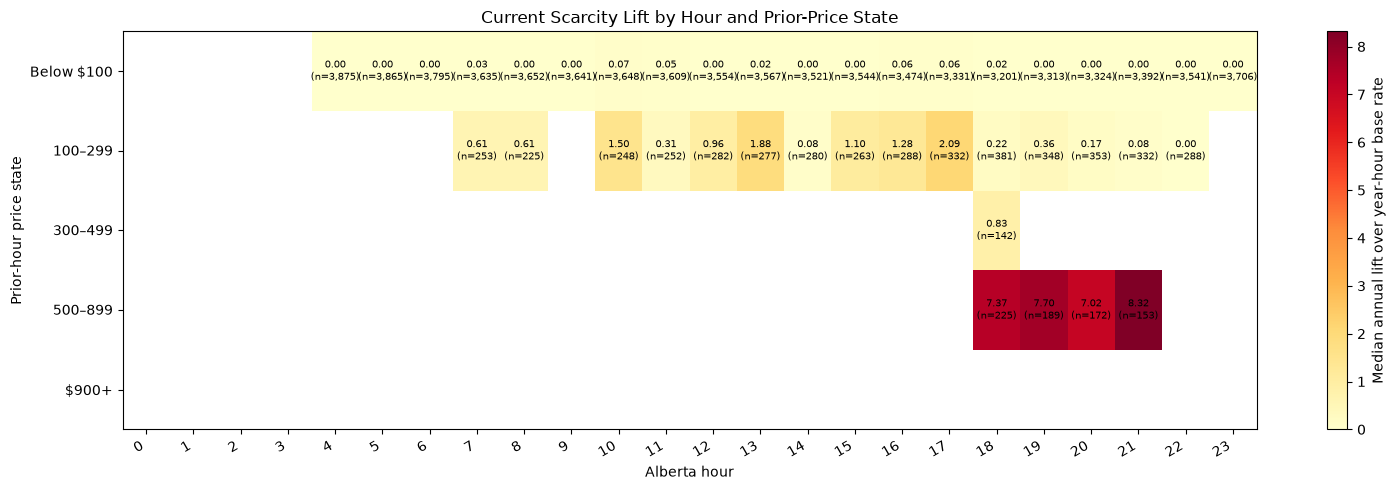

In [23]:
# ---------------------------------------------------------------------
# Test prior-price state after conditioning on year and hour
# ---------------------------------------------------------------------

calendar_memory_frame = pd.DataFrame({
    "year_alberta": master["year_alberta"],
    "hour_alberta": master["hour_alberta"],
    "prior_price_state": temporal_features["prior_price_state"],
    "scarcity_event": temporal_features["primary_scarcity_event"],
}).dropna()

overall_calendar_memory = (
    calendar_memory_frame
    .groupby(["prior_price_state", "hour_alberta"], observed=True)
    .agg(pooled_hours=("scarcity_event", "size"),
         pooled_scarcity_rate=("scarcity_event", "mean"))
    .reset_index()
)

annual_hour_base = (
    calendar_memory_frame
    .groupby(["year_alberta", "hour_alberta"])["scarcity_event"]
    .mean().rename("annual_hour_base_rate").reset_index()
)

annual_calendar_memory = (
    calendar_memory_frame
    .groupby(["year_alberta", "hour_alberta", "prior_price_state"], observed=True)
    .agg(annual_cell_hours=("scarcity_event", "size"),
         annual_cell_rate=("scarcity_event", "mean"))
    .reset_index()
    .merge(annual_hour_base, on=["year_alberta", "hour_alberta"], how="left")
)

annual_calendar_memory["annual_hour_adjusted_lift"] = (
    annual_calendar_memory["annual_cell_rate"] /
    annual_calendar_memory["annual_hour_base_rate"].replace(0, np.nan)
)

qualifying_annual_cells = annual_calendar_memory.loc[
    annual_calendar_memory["annual_cell_hours"].ge(MINIMUM_ANNUAL_CELL_HOURS)
    & annual_calendar_memory["annual_hour_adjusted_lift"].notna()
]

calendar_memory_stability = (
    qualifying_annual_cells
    .groupby(["prior_price_state", "hour_alberta"], observed=True)
    .agg(median_annual_hour_adjusted_lift=("annual_hour_adjusted_lift", "median"),
         years_qualifying=("year_alberta", "nunique"))
    .reset_index()
)

calendar_memory_summary = (
    overall_calendar_memory
    .merge(calendar_memory_stability,
           on=["prior_price_state", "hour_alberta"], how="left")
)

calendar_memory_summary["supported_lift"] = (
    calendar_memory_summary["median_annual_hour_adjusted_lift"]
    .where(
        calendar_memory_summary["pooled_hours"].ge(MINIMUM_CELL_HOURS) &
        calendar_memory_summary["years_qualifying"].ge(MINIMUM_YEARS_QUALIFYING)
    )
)

display(calendar_memory_summary.round(3))

plot_annotated_heatmap(
    calendar_memory_summary,
    row_column="prior_price_state",
    column_column="hour_alberta",
    value_column="supported_lift",
    count_column="pooled_hours",
    row_order=PRICE_STATE_ORDER,
    column_order=list(range(24)),
    title="Current Scarcity Lift by Hour and Prior-Price State",
    row_label="Prior-hour price state",
    column_label="Alberta hour",
    colorbar_label="Median annual lift over year-hour base rate",
)

### 6.1 Conditional results

Prior-price state remains informative after conditioning on year and hour, but the supported relationship is concentrated in the evening. A prior-hour price of $500–$899 is associated with current scarcity lifts of approximately 7–8 during hours 18–21, even relative to each year’s normal scarcity rate for the same hour. These cells satisfy the requirement for support across at least five years.

Moderately elevated prior prices of $100–$299 provide a weaker and less consistent signal. Their supported lifts are generally near one, with modest increases during parts of the daytime and a maximum of approximately 2.1 at hour 17. A prior price below $100 is associated with almost no current scarcity across all hours.

Calendar conditioning therefore materially reduces much of the pooled relationship for moderate prior prices, indicating that hour-of-day explains part of their apparent predictive value. Severe prior prices retain a strong evening association beyond normal calendar structure. However, the supported upper-price cells contain only about 150–225 pooled hours each, while most `$300–$499` and `$900+` combinations lack sufficient annual support and are suppressed rather than interpreted as zero effects.

This remains a conditional descriptive test. A time-based forecasting model is still required to determine whether lagged price adds genuine out-of-sample value beyond calendar features.

## 7. Evidence register

The evidence register classifies each temporal feature by:

1. mechanism;
2. relationship examined;
3. information timing;
4. redundancy;
5. event value;
6. forecast-time requirement; and
7. final analytical destination.

In [24]:
# ---------------------------------------------------------------------
# Create the Notebook 5 evidence register
# ---------------------------------------------------------------------

evidence_register = pd.DataFrame([
    {
        "feature_family": "Hour of day",
        "mechanism": "Recurring intraday demand, commitment, and market structure",
        "relationship_test": "Hourly price distribution and annual scarcity lift",
        "timing_status": "Known in advance",
        "redundant_with": "Hour sine/cosine and business-hour indicators",
        "event_value": "Identifies recurring onset windows",
        "forecast_requirement": "No transformation required",
        "final_classification": "Retain",
    },
    {
        "feature_family": "Weekday and weekend",
        "mechanism": "Recurring workweek demand pattern",
        "relationship_test": "Weekday × hour price-rank heatmap",
        "timing_status": "Known in advance",
        "redundant_with": "Day-of-week cyclical features",
        "event_value": "Provides calendar context",
        "forecast_requirement": "Use one categorical or cyclical representation",
        "final_classification": "Retain",
    },
    {
        "feature_family": "Month and season",
        "mechanism": "Recurring annual demand, weather, maintenance, and supply patterns",
        "relationship_test": "Month × hour price-rank heatmap",
        "timing_status": "Known in advance",
        "redundant_with": "Month, season, day-of-year and weather variables",
        "event_value": "Identifies seasonal event exposure",
        "forecast_requirement": "Test against explicit weather inputs",
        "final_classification": "Retain",
    },
    {
        "feature_family": "Holiday indicators",
        "mechanism": "Holiday-related demand changes",
        "relationship_test": "Matched year–month–weekday–hour price residual",
        "timing_status": "Known in advance",
        "redundant_with": "Weekday and business-hour features",
        "event_value": "Limited",
        "forecast_requirement": "Known holiday calendar",
        "final_classification": "Conditional",
    },
    {
        "feature_family": "Lagged pool price",
        "mechanism": "Persistence in physical conditions, offers, and market response",
        "relationship_test": "Lag decay, annual deciles, regimes, and event transitions",
        "timing_status": "Historical observation",
        "redundant_with": "Prior rolling mean, maximum, and prior price state",
        "event_value": "Identifies onset and continuation",
        "forecast_requirement": "Respect price-publication latency",
        "final_classification": "Retain",
    },
    {
        "feature_family": "Prior rolling price level",
        "mechanism": "Recent market-state persistence",
        "relationship_test": "Available for later baseline models",
        "timing_status": "Prior-only historical window",
        "redundant_with": "Multiple individual price lags",
        "event_value": "Summarizes recent elevated prices",
        "forecast_requirement": "Window must exclude target hour",
        "final_classification": "Conditional",
    },
    {
        "feature_family": "Prior rolling volatility",
        "mechanism": "Persistence of unstable market conditions",
        "relationship_test": "Decile gradient, annual stability, and episode duration",
        "timing_status": "Prior-only historical window",
        "redundant_with": "Lagged absolute changes and prior price range",
        "event_value": "Measures pre-event instability",
        "forecast_requirement": "Window must exclude target hour",
        "final_classification": "Conditional",
    },
    {
        "feature_family": "Prior scarcity state and run length",
        "mechanism": "Continuation of an active high-price episode",
        "relationship_test": "Continuation probability and episode duration",
        "timing_status": "Historical event information",
        "redundant_with": "Lagged price and rolling maximum",
        "event_value": "Directly measures continuation",
        "forecast_requirement": "Use only completed prior hours",
        "final_classification": "Conditional",
    },
    {
        "feature_family": "Current price state and price change",
        "mechanism": "Realized market outcome",
        "relationship_test": "Transition and event-aligned outcome",
        "timing_status": "Unknown before current hour",
        "redundant_with": "Current pool-price target",
        "event_value": "Defines realized onset and severity",
        "forecast_requirement": "Lag before use as a predictor",
        "final_classification": "Outcome only",
    },
])

display(evidence_register)

,feature_family,mechanism,relationship_test,timing_status,redundant_with,event_value,forecast_requirement,final_classification
0,Hour of day,"Recurring intraday demand, commitment, and mar...",Hourly price distribution and annual scarcity ...,Known in advance,Hour sine/cosine and business-hour indicators,Identifies recurring onset windows,No transformation required,Retain
1,Weekday and weekend,Recurring workweek demand pattern,Weekday × hour price-rank heatmap,Known in advance,Day-of-week cyclical features,Provides calendar context,Use one categorical or cyclical representation,Retain
2,Month and season,"Recurring annual demand, weather, maintenance,...",Month × hour price-rank heatmap,Known in advance,"Month, season, day-of-year and weather variables",Identifies seasonal event exposure,Test against explicit weather inputs,Retain
3,Holiday indicators,Holiday-related demand changes,Matched year–month–weekday–hour price residual,Known in advance,Weekday and business-hour features,Limited,Known holiday calendar,Conditional
4,Lagged pool price,"Persistence in physical conditions, offers, an...","Lag decay, annual deciles, regimes, and event ...",Historical observation,"Prior rolling mean, maximum, and prior price s...",Identifies onset and continuation,Respect price-publication latency,Retain
5,Prior rolling price level,Recent market-state persistence,Available for later baseline models,Prior-only historical window,Multiple individual price lags,Summarizes recent elevated prices,Window must exclude target hour,Conditional
6,Prior rolling volatility,Persistence of unstable market conditions,"Decile gradient, annual stability, and episode...",Prior-only historical window,Lagged absolute changes and prior price range,Measures pre-event instability,Window must exclude target hour,Conditional
7,Prior scarcity state and run length,Continuation of an active high-price episode,Continuation probability and episode duration,Historical event information,Lagged price and rolling maximum,Directly measures continuation,Use only completed prior hours,Conditional
8,Current price state and price change,Realized market outcome,Transition and event-aligned outcome,Unknown before current hour,Current pool-price target,Defines realized onset and severity,Lag before use as a predictor,Outcome only


### 7.1 Evidence summary

The descriptive evidence supports carrying forward hour of day, one weekday representation, and one seasonal representation as a compact candidate calendar set. Hour is the dominant calendar feature; weekday or weekend status provides secondary workweek context, while month or season captures recurring annual variation. Each cycle should use either categorical variables or cyclical transformations—not both. Holiday indicators remain conditional because their median matched residual is near zero after controlling for year, month, weekday, and hour, but uncertainty and year-level stability have not been tested.

Lagged pool price is the strongest market-memory family. The one-hour lag contains the most immediate information, while the 24- and 168-hour relationships may reflect daily and weekly recurrence, persistent market conditions, or both. Nearby short lags are likely redundant with the one-hour lag, but formal redundancy and incremental value remain questions for chronological validation.

Prior rolling volatility consistently identifies unstable conditions and elevated tail risk, but its incremental value beyond the one-hour price lag has not been established. It therefore remains conditional, as do prior scarcity state and run length. These measures summarize different aspects of recent conditions but overlap substantially with lagged price and rolling maximum, so their additional value must be tested jointly.

Calendar variables are known in advance. Lagged prices, rolling price levels, volatility, and completed scarcity run length are forecast-eligible only when constructed entirely from observations published before the forecast origin. Current-hour price state, price change, scarcity status, and event severity remain outcomes; they may be used as predictors only after being lagged. Formal redundancy and feature selection therefore remain part of time-based out-of-sample validation.

### 7.2 Deferred analyses

| Analysis | Destination | Reason |
|---|---|---|
| Physical scarcity drivers | Notebook 2 | Available margin, outages, imports and thermal availability |
| Fuel-cost relationships | Notebook 3 | Gas prices and marginal-generation economics |
| Weather and renewable availability | Notebook 4 | Temperature, wind, solar and hydro mechanisms |
| Exhaustive lag selection | Notebooks 6–8 | Must be evaluated out of sample |
| Calendar-feature regularization | Notebooks 6–8 | Model-dependent |
| Probability calibration | Notebooks 7–8 | Requires held-out predictions |
| Forecast-error analysis | Notebooks 6–8 | Requires forecast vintages and predictions |
| Trading or bidding rules | Notebook 9 | Requires validated forecasts and transaction assumptions |

## 8. Conclusion

This notebook identifies recurring calendar structure and market memory in Alberta pool prices from 2015–2025.

**Calendar structure.** Typical prices are lowest overnight and highest in the late afternoon, while upper-tail prices and scarcity are concentrated more sharply around hours 16–20. Weekday, seasonal, and month–hour patterns remain visible after using within-year price ranks. The median matched holiday residual is near zero, so holiday indicators remain conditional pending uncertainty and stability testing.

**Price persistence.** The one-hour price lag is the strongest temporal signal: its Spearman correlation with current price is 0.956, and its highest within-year decile is associated with a 21.7% scarcity rate and 8.6-times lift. Severe prior prices retain strong evening separation after conditioning on year and hour. The rebounds at 24 and 168 hours indicate daily and weekly recurrence, persistent market conditions, or both; they do not establish independent long-horizon market memory.

**Volatility and event memory.** High prior volatility identifies larger subsequent price movements and elevated tail risk, but its incremental value beyond the prior-hour price remains unresolved. Scarcity generally begins from already elevated prices, continuation becomes more likely as an event persists, and most events remain short: median duration is two hours and 90% end within eight. The longer persistence of rolling volatility is partly mechanical because shocks remain in its trailing window.

**Forecast handoff.** Hour, weekday, season, and known holidays are available in advance. Lagged prices, rolling price summaries, volatility, and completed event history are eligible only when based entirely on information available before the forecast origin. Current price, price change, scarcity status, and event severity remain outcomes. Notebook 6 must use chronological validation to determine which calendar representations and historical-price features add non-redundant out-of-sample value.